In [1]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random
from ai_edge_litert.interpreter import Interpreter
from training.dice_score.dataset import (
    S7DatasetDiceClassification,
    S7DatasetDiceClassificationConfig
)
from training.dice_score.data import get_dice_crops

from training.dice_detection.dataset import (
    S7DatasetDiceDetection,
    S7DatasetDiceDetectionConfig,
    get_image_detection_datas
)

from ults.config import load_config
from ults.setup import tf_init

from inference.dice_detection.inference import DiceDetectionInference
from inference.dice_score.inference import DiceScoreInference

2026-02-27 09:00:03.935851: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-27 09:00:03.949209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-27 09:00:03.962548: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-27 09:00:03.966490: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-27 09:00:03.978576: I tensorflow/core/platform/cpu_feature_guar

In [2]:
tf_init()

In [3]:
# Load configuration
config = load_config("config/train.yml")
print(f"Dataset path: {config.dataset_path}")

Dataset path: ../datasets/s7dataset-2-dice-detection


## Test Dice Detection Model

In [4]:
# Load the trained detection model (TFLite)

dice_detection_inference = DiceDetectionInference(model_path="models/dice_detection/model.tflite")

INFO: Created TensorFlow Lite delegate for select TF ops.
I0000 00:00:1772182808.495315   87808 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772182808.579980   87808 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772182808.580015   87808 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772182808.714426   87808 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772182808.714479   87808 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your k

In [5]:
# Visualize detection model predictions with bounding boxes
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Recreate generator for visualization
image_datas = get_image_detection_datas(config.dataset_path, config.num_workers)
dice_detection_dataset = S7DatasetDiceDetection(
    config=S7DatasetDiceDetectionConfig(dataset_path=config.dataset_path),
    image_datas=image_datas
)

def generate_dice_detection():
    for img, lbl in dice_detection_dataset:
        yield img, lbl
        
dice_detection_generator = generate_dice_detection()

I0000 00:00:1772182809.136469   87808 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772182809.136523   87808 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772182809.136533   87808 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772182809.137006   87808 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772182809.137026   87808 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

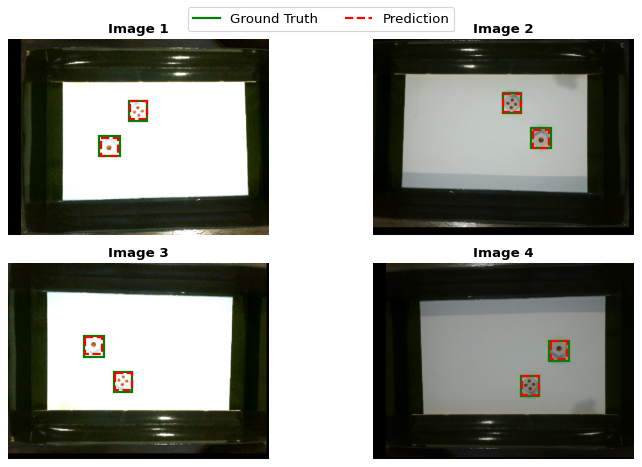

In [6]:
import time

# Determine number of images to display (up to 8)
num_viz_images = 4

# Create figure
rows = 2
cols = 2
fig, axes = plt.subplots(rows, cols, figsize=(10, 6), dpi=80)
axes = axes.flatten()

for i in range(num_viz_images):
    ax = axes[i]

    # Get next image and bboxes from generator
    img, bboxes = next(dice_detection_generator)
    ax.imshow(img)

    # Draw ground truth bounding boxes in green
    for bbox in bboxes:
        x, y, w, h = bbox
        rect = Rectangle(
            (x, y),
            w, h,
            linewidth=2,
            edgecolor="green",
            facecolor="none",
            label="Ground Truth",
        )
        ax.add_patch(rect)

    boxes = dice_detection_inference(img)
    for box in boxes:
        x, y, w, h = box
        rect = Rectangle((x, y), w, h,
                       linewidth=2, edgecolor='red',
                       facecolor='none', linestyle='--')
        ax.add_patch(rect)

    ax.set_title(f'Image {i+1}', fontsize=12, fontweight='bold')
    ax.axis('off')

# Hide unused subplots
for i in range(num_viz_images, rows * cols):
    axes[i].axis('off')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', linewidth=2, label='Ground Truth'),
    Line2D([0], [0], color='red', linewidth=2, linestyle='--', label='Prediction')
]
fig.legend(handles=legend_elements, loc='upper center', 
          bbox_to_anchor=(0.5, 0.98), ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Test Dice Score Classification Model

In [7]:
# Load dice crops for score classification
dice_crops = get_dice_crops(dataset_path=config.dataset_path, num_workers=4)
print(f"Loaded {len(dice_crops)} dice crops")

# Load dataset
dataset = S7DatasetDiceClassification(
    config=S7DatasetDiceClassificationConfig(
        image_resolution=(32, 32)
    ),
    dice_crops=dice_crops
)

Loaded 1000 dice crops


In [8]:
def generate_dice_score():
    for img, lbl in dataset:
        yield img, lbl
        
dice_score_generator = generate_dice_score()

In [9]:
# Load the trained score classification model (TFLite)
dice_score_inference = DiceScoreInference(model_path="models/dice_score/model.tflite")

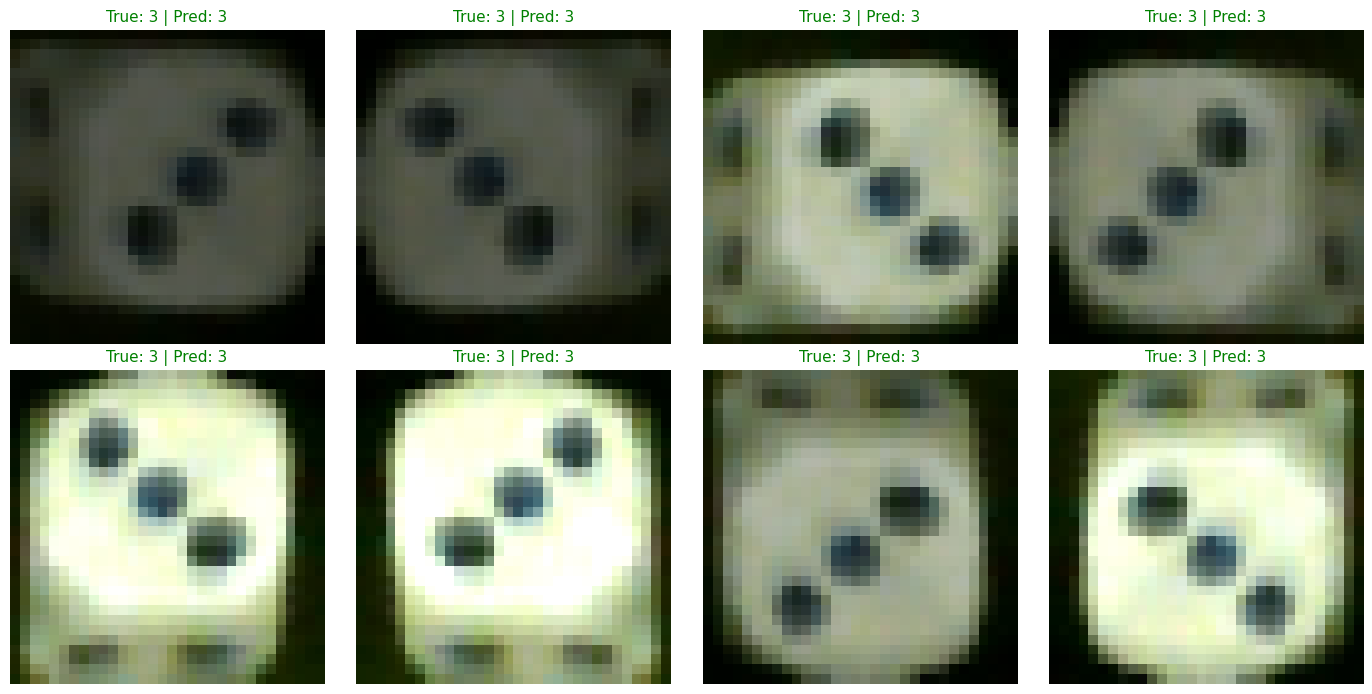

Green = Correct prediction, Red = Incorrect prediction


In [11]:
# Visualize score classification predictions
num_viz_images = 8

# Create figure
rows = 2
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(14, 7))
axes = axes.flatten()

for i in range(num_viz_images):
    ax = axes[i]

    # Get next image and label from generator
    img, lbl = next(dice_score_generator)
    ax.imshow(img.squeeze(), cmap='gray')

    true_score = lbl + 1  # Convert 0-5 to 1-6
    pred_score = dice_score_inference(img)
    
    # Green if correct, red if incorrect
    color = 'green' if true_score == pred_score else 'red'
    ax.set_title(f"True: {true_score} | Pred: {pred_score}", color=color, fontsize=11)
    ax.axis('off')

# Hide unused subplots if any
for i in range(num_viz_images, rows * cols):
    axes[i].axis('off')

plt.tight_layout()
plt.show()
print("Green = Correct prediction, Red = Incorrect prediction")